# Graphing
- In this file, I will be exploring my data through scatterplots and correlation heatmaps

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("data/FINAL_DF.csv")

The following values are written as percentages, and I want them to be written as decimals

In [4]:
df["% >= HS"] = df["% >= HS"] / 100
df["% >= Bachelor's"] = df["% >= Bachelor's"] / 100
df["Pov for 25<=, >=Bachelor's"] = df["Pov for 25<=, >=Bachelor's"] / 100
df["Pov for 25yo<=, <HS"] = df["Pov for 25yo<=, <HS"] / 100

In [6]:
df.to_csv('data/FINAL_DF.csv', index=False) # updating csv

In [5]:
df.head()

,Geography,LocYear,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0400000US01,AL2010,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,0400000US02,AK2010,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,0400000US04,AZ2010,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0400000US05,AR2010,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0400000US06,CA2010,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


## Scatterplots
- These are to visually see correlations

In [22]:
y = df["HFR"] # response variable

In [23]:
X = df["% >= HS"] # explanatory

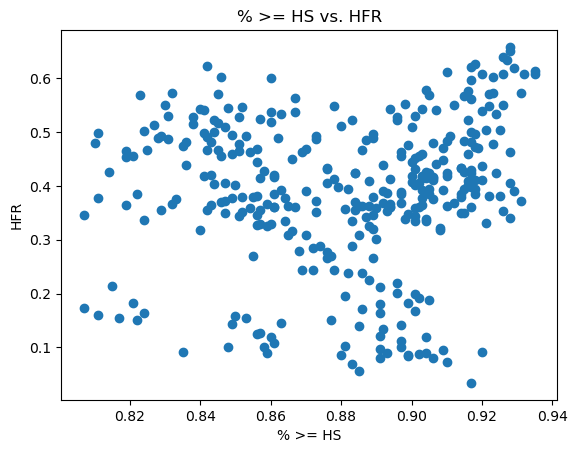

In [27]:
# testing out scatterplot
plt.scatter(X, y)
plt.xlabel("% >= HS")
plt.ylabel("HFR")
plt.title("% >= HS vs. HFR")
plt.show()

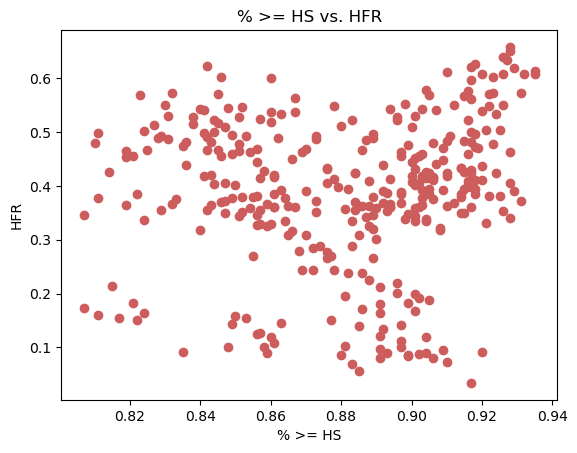

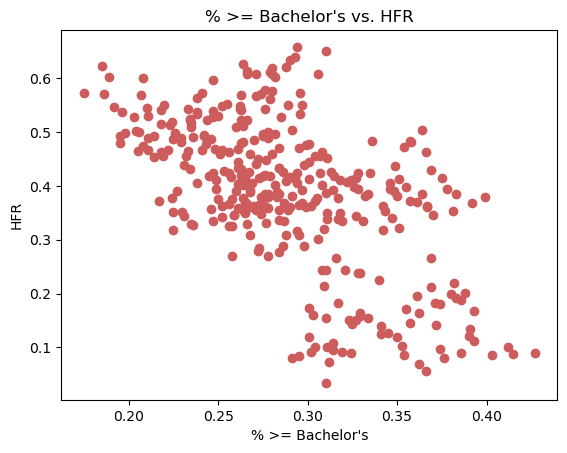

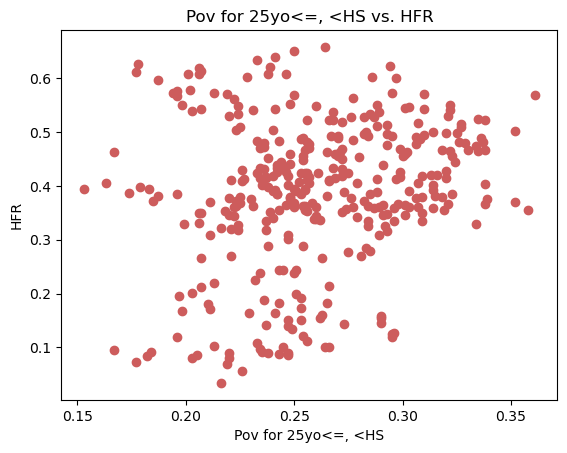

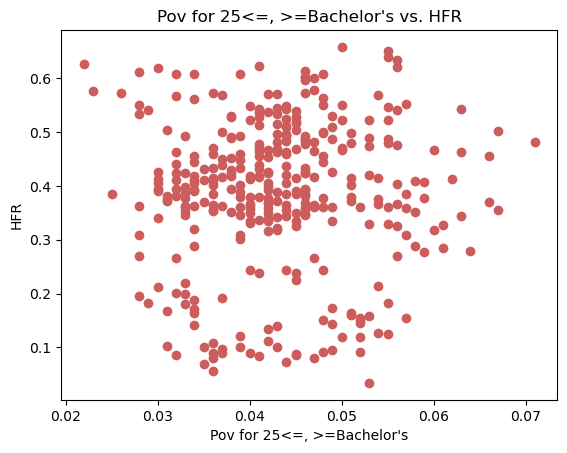

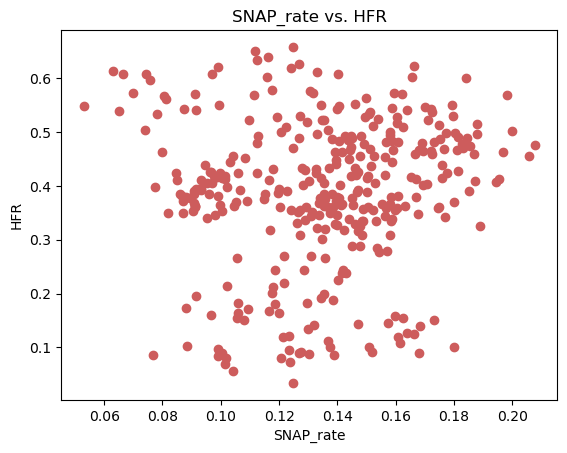

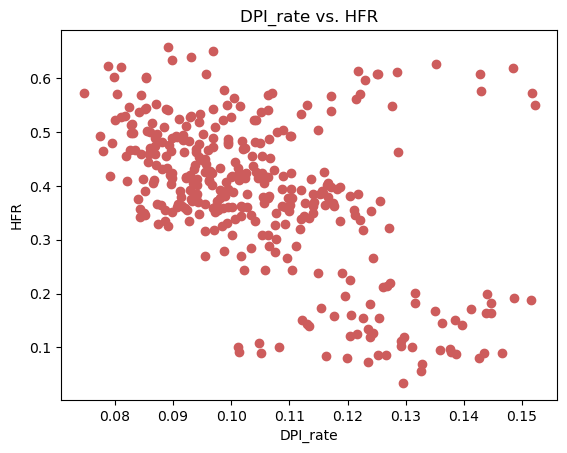

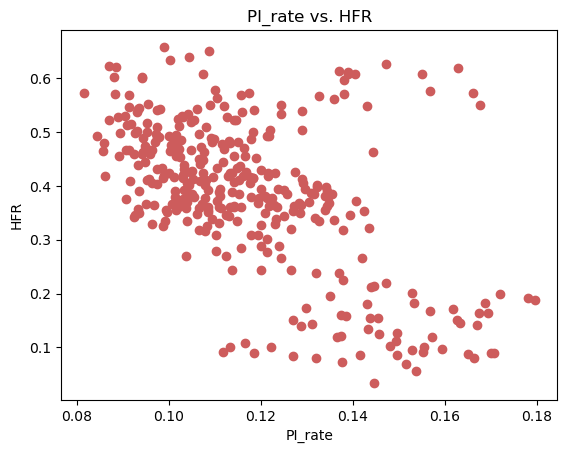

In [41]:
# scatterplot function to streamline proccess
def make_scatterplots(df):
    for col_name in df:
        y = df["HFR"]
        if (col_name != "Geography") and (col_name != "LocYear") and (col_name != "HFR") and (col_name != "GeoFIPS"):
            X = df[col_name]
            plt.scatter(X, y, color="indianred")
            plt.xlabel(col_name)
            plt.ylabel("HFR")
            plt.title(col_name + " vs. HFR")
            plt.show()

make_scatterplots(df)

In [42]:
df.head()

,Geography,LocYear,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0400000US01,AL2010,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,0400000US02,AK2010,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,0400000US04,AZ2010,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0400000US05,AR2010,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0400000US06,CA2010,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


## Correlation Heatmap

In [44]:
# these are the only columns I want in the heatmap
new_df = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "DPI_rate", "PI_rate", "HFR"]] 

In [45]:
new_df.head()

,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS",SNAP_rate,DPI_rate,PI_rate,HFR
0,0.821,0.219,0.300,0.147621,0.082011,0.089287,0.456
1,0.910,0.279,0.177,0.132925,0.128447,0.138935,0.611
2,0.856,0.259,0.301,0.139955,0.085180,0.092639,0.346
3,0.829,0.195,0.267,0.142676,0.077484,0.084426,0.493
4,0.807,0.301,0.253,0.087893,0.115410,0.129771,0.174


                      % >= HS  % >= Bachelor's  Pov for 25yo<=, <HS  \
% >= HS              1.000000         0.481633            -0.654171   
% >= Bachelor's      0.481633         1.000000            -0.507095   
Pov for 25yo<=, <HS -0.654171        -0.507095             1.000000   
SNAP_rate           -0.492931        -0.419034             0.683240   
DPI_rate             0.331322         0.693321            -0.597840   
PI_rate              0.321067         0.728947            -0.571577   
HFR                  0.098824        -0.590871             0.201646   

                     SNAP_rate  DPI_rate   PI_rate       HFR  
% >= HS              -0.492931  0.331322  0.321067  0.098824  
% >= Bachelor's      -0.419034  0.693321  0.728947 -0.590871  
Pov for 25yo<=, <HS   0.683240 -0.597840 -0.571577  0.201646  
SNAP_rate             1.000000 -0.485201 -0.464181  0.074099  
DPI_rate             -0.485201  1.000000  0.993202 -0.511729  
PI_rate              -0.464181  0.993202  1.000000 -0

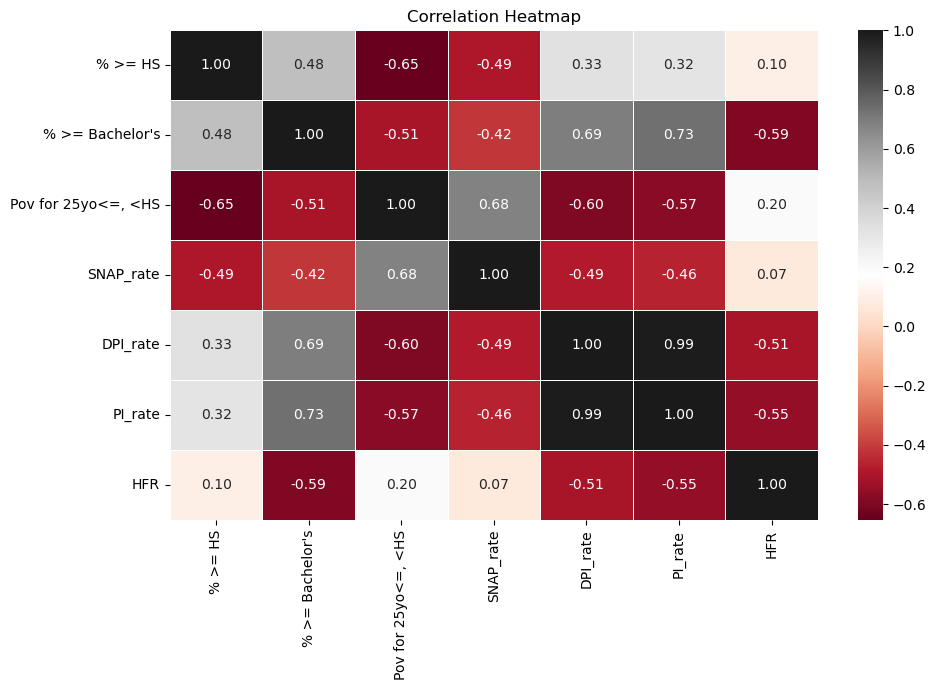

In [49]:
def make_heatmap(x, cmap='RdGy', title="Correlation Heatmap"):
    matrix = x.corr()
    print(matrix)
    plt.figure(figsize=(10,7))
    sns.heatmap(matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

make_heatmap(new_df)